# 46750 Assignment 1 - Completed Q1(a)-(f)

This notebook extends the existing Q1 derivations, uses the unchanged course data, and includes executed numerical evidence. Run All to reproduce the outputs. The first cell locates the companion project automatically on this computer. Hours are 0-23.

**Charts:** Section (f) includes hourly dispatch/price bars, daily comparison bars, and dual-multiplier bars. Saved chart outputs are included.

**AI disclosure:** OpenAI Codex assisted with derivations, model implementation, numerical checks and writing. The actual checks are documented below. The group must add its member information, contribution table and actual human review before submission.

# Question 1 - Price-elastic hourly consumption

This section completes Q1(a)-(e). Executed code, figures, hourly verification tables and numerical discussion for Q1(f) are in `Q1_completed.ipynb`. The starting point is the formulation in the supplied `notes(1) (1).ipynb`. Hours are indexed **0-23**, matching the input files. All results use the supplied first-day data, unchanged.

### Course basis and scope

References below use **PDF page numbers (starting at 1)**, not slide footer numbers. The four supplied lecture files are abbreviated as follows:

| Reference | Supplied lecture | Pages used and application |
|---|---|---|
| [Intro] | Introduction to optimization for power system decisions (redacted version) | 10: standard form; 15: model validation workflow |
| [Duality] | Duality and Optimality Conditions (full version) (2) | 24: convexity; 48-50: weak/strong duality and weak Slater; 53, 55-66: Lagrangian and dual derivation; 85: KKT; 86: sensitivity |
| [ED] | From ED to OPF - Student slides (redacted version) | 11, 13-14: independent hourly dispatch, continuous bounds, linear costs/utilities and balance |
| [Pricing] | [Lecture Slides] Pricing in electricity markets (2) | 20-25: bound/interior dispatch and nonunique prices; 42-43: price-taking self-scheduling; 69: flexible-load KKT |

The method follows these lectures; the tariff-adjusted price ladder is **derived here for the assignment**, not quoted as a formula from the slides. Q1 is a single prosumer's price-taking self-scheduling problem: the market price is an input. It is not system-wide market clearing or a network OPF, so no voltage, line-flow or intertemporal constraints are introduced. The supplied assignment defines the requested scope; the slides provide the mathematical tools.



## (a) Formulation, properties and hourly decomposition

### Notation and units

| Symbol | Type / unit | Meaning |
|---|---|---|
| $t\in\mathcal T=\{0,\ldots,23\}$ | Index | One-hour period |
| $l=L^{\min},\ M=L^{\max}$ | Parameter, kWh per hour | Lower / upper hourly load |
| $V_t=PV_t^{\max}$ | Parameter, kWh per hour | Available PV generation |
| $u=u^L$ | Parameter, DKK/kWh | Marginal consumption utility |
| $c=c^{PV}$ | Parameter, DKK/kWh | Marginal cost of actual PV generation |
| $p_t$ | Parameter, DKK/kWh | Market electricity price |
| $\tau^{imp},\tau^{exp}$ | Parameter, DKK/kWh | Positive import / export tariffs |
| $a_t=p_t+\tau^{imp}$ | Derived, DKK/kWh | Effective import price |
| $b_t=p_t-\tau^{exp}$ | Derived, DKK/kWh | Effective export revenue per kWh |
| $L_t,G_t,I_t,X_t$ | Decision, kWh per hour | Load, actual PV, import and export |
| $\lambda_t$ | Dual, DKK/kWh | Balance multiplier in the minimization Lagrangian |
| $\alpha_t^-,\alpha_t^+$ | Nonnegative dual, DKK/kWh | Lower / upper load bounds |
| $\beta_t^-,\beta_t^+$ | Nonnegative dual, DKK/kWh | Lower / upper PV bounds |
| $\gamma_t^I,\gamma_t^X$ | Nonnegative dual, DKK/kWh | Nonnegative import / export bounds |

The one-hour duration is absorbed into the hourly energy quantities. For powers over a general time step, energy costs and energy totals require the factor $\Delta t$.

For direct comparison with [Pricing, p. 69], our load multipliers $\alpha^-,\alpha^+$ are the lecture's $\underline\nu,\overline\nu$, and our PV multipliers $\beta^-,\beta^+$ are its generator multipliers $\underline\mu,\overline\mu$. These are only notation changes. The additional $\gamma^I,\gamma^X$ describe the assignment's directed grid exchanges. We retain the original notebook's symbols consistently throughout.

The gross utility, net procurement cost (including PV production), and net surplus are

$$U=\sum_t uL_t,\qquad C=\sum_t(cG_t+a_tI_t-b_tX_t),\qquad S=U-C.$$

The daily problem is

$$\begin{aligned}
\max_{L,G,I,X}\quad &\sum_{t\in\mathcal T}(uL_t-cG_t-a_tI_t+b_tX_t)\\
\text{s.t.}\quad &L_t+X_t-G_t-I_t=0 &&\forall t,\\
&l\le L_t\le M &&\forall t,\\
&0\le G_t\le V_t &&\forall t,\\
&I_t\ge0,\ X_t\ge0 &&\forall t.
\end{aligned}$$

The balance equates demand plus exports with PV plus imports. The remaining constraints represent physical load/PV limits and nonnegative directed grid exchanges. Simultaneous import/export is not prohibited by an extra nonlinear constraint: the strictly positive tariff spread makes it suboptimal, as proved in (d)(i).

This is an LP and therefore a convex optimization problem. With finite parameters, $0\le l\le M<\infty$ and $0\le V_t<\infty$, it is feasible: set $L_t=l,G_t=0,I_t=l,X_t=0$. More generally any admissible $L_t,G_t$ can be balanced using unrestricted grid exchange.

For a feasible instance with finite load/PV bounds, the objective is bounded above **if and only if** $a_t\ge b_t$ for every hour. If $b_t>a_t$, simultaneously increasing $I_t,X_t$ makes surplus unbounded. If $a_t\ge b_t$, write any balanced exchange as its minimum required exchange plus an equal nonnegative increment in import and export; this increment contributes $-(a_t-b_t)$ times its size and cannot improve surplus. The remaining load/PV choices lie in a compact rectangle, so a finite optimum is attained. The feasible set itself remains unbounded in grid exchanges even when the optimal objective is bounded. Here $a_t-b_t=\tau^{imp}+\tau^{exp}=0.9>0$.

There are 96 continuous variables, 24 balance equations and 144 explicit bound inequalities (six per hour). Bounds could alternatively be stored as variable bounds, but explicit rows permit direct extraction of every multiplier.

The hourly subproblem is the same formulation with a fixed $t$ and objective $uL-cG-aI+bX$. Since the feasible set is a Cartesian product of hourly sets and the objective is additive,

$$\max_{x_t\in\mathcal F_t,\,t\in\mathcal T}\sum_t S_t(x_t)
=\sum_t\max_{x_t\in\mathcal F_t}S_t(x_t).$$

Thus 24 independent four-variable LPs replace one 96-variable LP. Independent solves can run in parallel and require work proportional to the horizon when each hourly problem has fixed size; actual speed depends on solver overhead, so separate solves need not be faster for this tiny dataset. Economically there is no load shifting across hours: consumption foregone in one hour need not be recovered later. Each hour is a separate utility-versus-energy-cost decision.



## (b) Lagrangian, dual problem, KKT and strong duality

For one hour, omit $t$ and minimize negative surplus,

$$F=-uL+cG+aI-bX.$$

Use the equality $h=L+X-G-I=0$ and inequalities $l-L\le0$, $L-M\le0$, $-G\le0$, $G-V\le0$, $-I\le0$, $-X\le0$. Treat the four primal variables as free when forming the Lagrangian, since all bounds are represented explicitly:

$$\begin{aligned}
\mathcal L={}&-uL+cG+aI-bX+\lambda(L+X-G-I)\\
&+\alpha^-(l-L)+\alpha^+(L-M)\\
&-\beta^-G+\beta^+(G-V)-\gamma^I I-\gamma^X X.
\end{aligned}$$

Following [Intro, p. 10] and [Duality, pp. 53, 55-66], the steps are: write the minimization standard form, attach multipliers, collect coefficients, and take the infimum over the primal variables. All inequality multipliers are nonnegative; $\lambda$ is unrestricted. In particular,

$$\begin{aligned}
\mathcal L={}&(-u+\lambda-\alpha^-+\alpha^+)L
+(c-\lambda-\beta^-+\beta^+)G\\
&+(a-\lambda-\gamma^I)I+(-b+\lambda-\gamma^X)X
+\alpha^-l-\alpha^+M-\beta^+V.
\end{aligned}$$

Because the primal variables are free in this infimum,

$$q(\lambda,\alpha,\beta,\gamma)=\inf_{L,G,I,X}\mathcal L
=\begin{cases}
\alpha^-l-\alpha^+M-\beta^+V,&\text{all four variable coefficients are zero},\\
-\infty,&\text{otherwise}.
\end{cases}$$

A nonzero coefficient permits its free variable to tend in the direction that makes the Lagrangian arbitrarily negative. Maximizing this lower bound yields the dual LP:

$$\begin{aligned}
\max\quad &\alpha^-l-\alpha^+M-\beta^+V\\
\text{s.t.}\quad &-u+\lambda-\alpha^-+\alpha^+=0,\\
&c-\lambda-\beta^-+\beta^+=0,\\
&a-\lambda-\gamma^I=0,\\
&-b+\lambda-\gamma^X=0,\\
&\alpha^-,\alpha^+,\beta^-,\beta^+,\gamma^I,\gamma^X\ge0,\quad\lambda\in\mathbb R.
\end{aligned}$$

The KKT conditions are these four stationarity equations and dual feasibility, together with primal feasibility from (a) and complementary slackness:

$$\begin{aligned}
\alpha^-(L-l)&=0,&\alpha^+(M-L)&=0,\\
\beta^-G&=0,&\beta^+(V-G)&=0,\\
\gamma^I I&=0,&\gamma^X X&=0.
\end{aligned}$$

These are precisely the four KKT groups in [Duality, p. 85]: primal feasibility, dual feasibility, stationarity and complementary slackness. The objective and inequalities are affine (hence convex), and the equality is affine. The **weak Slater condition** in [Duality, pp. 49-50] requires strict inequalities only for nonlinear inequality constraints; linear inequalities may hold at equality. The feasible point constructed in (a) therefore satisfies this condition. With the finite optimum established in (a), strong duality holds and KKT is necessary and sufficient for optimality. At night $V=0$ prevents both PV bounds from being strict, but does not invalidate weak Slater or LP strong duality.

The dual objective equals the minimum negative surplus $F^*=-S^*$, **not** $S^*$. Daily primal and dual objectives are sums over hours.



## (c) Economic interpretation and uniqueness of the duals

Here $p$ is the **given market price**, whereas $\lambda$ is the prosumer's **local balance shadow price**. Their distinction follows the price-taking interpretation in [Pricing, pp. 42-43]; $\lambda$ need not equal $p$ because imports and exports face different tariffs.

Grid stationarity implies

$$b\le\lambda\le a,\qquad\gamma^I=a-\lambda,\qquad\gamma^X=\lambda-b.$$

Although $\lambda$ is declared unrestricted, the optimality conditions bound it between the effective export and import prices. In this dataset it is positive.

* If importing, $I>0$ implies $\gamma^I=0$ and **$\lambda=a$**: another kWh costs the effective import price.
* If exporting, $X>0$ implies $\gamma^X=0$ and **$\lambda=b$**: another kWh of local consumption sacrifices export revenue.
* If $I=X=0$ and $l<L<M$, the two load-bound multipliers vanish and **$\lambda=u$**. At an interior load optimum, marginal energy value equals consumption utility. No grid exchange alone does not guarantee this equality when a load bound is active.

For a precise sign convention, perturb the balance to $L+X-G-I=\delta$, where $\delta$ is externally supplied free energy. Then $dF^*/d\delta=-\lambda$ and $dS^*/d\delta=\lambda$, whenever the value function is differentiable. Equivalently, an exogenous extra demand entering the left-hand side raises minimum cost by $\lambda$ per kWh.

At nondegenerate points, the bounds have the sensitivity interpretations

$$\frac{\partial S^*}{\partial V}=\beta^+,\qquad
\frac{\partial S^*}{\partial M}=\alpha^+,\qquad
\frac{\partial S^*}{\partial l}=-\alpha^-.$$

Increasing PV availability and maximum permitted consumption can improve surplus; reducing the minimum-load requirement can improve surplus by $\alpha^-$ per unit. A slack bound has zero multiplier. An active bound may still have zero multiplier, so binding is not sufficient to establish a positive value.

For distinct load bounds, stationarity gives

$$\alpha^-=\max(\lambda-u,0),\qquad\alpha^+=\max(u-\lambda,0).$$

For $V>0$, complementary slackness gives

$$\beta^+=\max(\lambda-c,0),\qquad\beta^-=\max(c-\lambda,0).$$

Thus PV availability is valuable when its energy value exceeds production cost. At $V=0$ both PV bounds are active, and only $\beta^+-\beta^-=\lambda-c$ is pinned down. Adding the same nonnegative constant to both multipliers preserves stationarity, complementarity and the dual objective. Individual PV multipliers need not be unique even if all primal variables are unique.

The precise lecture statement is [Duality, p. 86]: if the constraints are perturbed to $g(x)\le r$, $h(x)=v$, an optimal base-case multiplier gives

$$F^*(r,v)\ge F^*(0,0)-\mu^{*T}r-\lambda^{*T}v.$$

The derivatives equal the negative multipliers when the value function is differentiable. At a breakpoint, an arbitrary optimal multiplier need not equal the finite-difference derivative in a chosen direction. In particular, with $V=0$ the right-hand marginal value of introducing PV is $\max(\lambda-c,0)$ when the local energy value is unique; a larger admissible $\beta^+$ from the dual ray must not be interpreted as an additional physical benefit. Section (f) computes full dual ranges to distinguish solver-selected values from uniquely identified sensitivities.



## (d) Price ladder for Case A: $c<u$

### (i) Why import and export cannot both be positive

If $I>0$ and $X>0$, complementarity and stationarity imply $\lambda=a$ and $\lambda=b$, contradicting $a-b=\tau^{imp}+\tau^{exp}>0$. Equivalently, reducing both exchanges by $\varepsilon>0$ preserves balance and improves surplus by $(a-b)\varepsilon$.

The relevant condition is strictly positive round-trip tariff spread $a>b$, not merely a positive market price. If $a=b$, simultaneous exchanges are cost-neutral and can be optimal; if $a<b$, unrestricted arbitrage makes the problem unbounded. No binary variables are needed for Q1.

### (ii) Three load regimes, initially $l<V<M$

First apply the lecture's lower-bound/interior/upper-bound reasoning [Pricing, pp. 20-24, 69]. For $l<M$ and $V>0$, stationarity and complementary slackness give:

| Variable state | Zero multiplier(s) | Required marginal-value relation |
|---|---|---|
| $L=l$ | $\alpha^+=0$ | $\lambda=u+\alpha^-\ge u$ |
| $l<L<M$ | $\alpha^-=\alpha^+=0$ | $\lambda=u$ |
| $L=M$ | $\alpha^-=0$ | $\lambda=u-\alpha^+\le u$ |
| $G=0$ | $\beta^+=0$ | $\lambda=c-\beta^-\le c$ |
| $0<G<V$ | $\beta^-=\beta^+=0$ | $\lambda=c$ |
| $G=V$ | $\beta^-=0$ | $\lambda=c+\beta^+\ge c$ |

These are implications for an optimal point, not six independent choices: energy balance and the grid conditions must also hold. Combining them with $b\le\lambda\le a$ gives the assignment-specific ladder below.

Away from ties, the Case A load rule is

$$L^*=\begin{cases}
M,&u>a,\\
V,&b<u<a,\\
l,&u<b.
\end{cases}$$

**Low import price, $u>a$:** load stationarity and $\lambda\le a<u$ force $L=M$. Consumption utility exceeds the maximum marginal grid procurement price. Load is maximized, and imports cover any shortfall after economically chosen PV generation.

**Intermediate regime, $b<u<a$:** consumption is worth more than exports but less than imports. Since $c<u$, producing PV to consume is worthwhile. $L<V$ would permit another unit of profitable self-consumption (either avoiding curtailment at cost $c<u$ or giving up export revenue $b<u$); $L>V$ would require an import costing $a>u$. Hence $L=G=V$, $I=X=0$, and $\lambda=u$.

**High export value, $u<b$:** because $\lambda\ge b>u$, load stationarity forces $L=l$. Here $c<u<b$, so producing all available PV is profitable. The prosumer exports $V-l$ instead of consuming above the minimum.

These arguments construct primal/dual KKT optima; strong duality guarantees that the resulting surplus is globally optimal. The switches occur at $u=a$ and $u=b$, where an incremental change of load becomes cost-neutral.

For an explicit KKT certificate under $l<V<M$, the nonnegative multipliers can be chosen as follows (unlisted load multipliers are zero):

| Regime | $\lambda$ | Load multiplier | $\beta^+$ | $\beta^-$ | $\gamma^I$ | $\gamma^X$ |
|---|---|---|---|---|---|---|
| $u>a$ | $a$ | $\alpha^+=u-a$ | $(a-c)_+$ | $(c-a)_+$ | $0$ | $a-b$ |
| $b<u<a$ | $u$ | Both zero | $u-c$ | $0$ | $a-u$ | $u-b$ |
| $u<b$ | $b$ | $\alpha^-=b-u$ | $b-c$ | $0$ | $a-b$ | $0$ |

Together with the corresponding load/PV/grid choices, these satisfy every stationarity and complementary-slackness equation. This supplies a direct KKT proof without numerical optimization.

### (iii) PV production, curtailment and cost thresholds

For any fixed optimal load $L$, define $s=\min(L,V)$. A unit of PV used locally avoids imports worth $a$; a unit produced beyond local consumption earns $b$. Consequently the optimal PV set is

$$G^*\in\begin{cases}
\{0\},&c>a,\\
[0,s],&c=a,\\
\{s\},&b<c<a,\\
[s,V],&c=b,\\
\{V\},&c<b.
\end{cases}$$

This rule is also a direct consequence of PV stationarity and $\lambda=a$ when importing / $\lambda=b$ when exporting. Curtailment is $V-G^*$; an unavailable PV resource $V=0$ is not a positive curtailment opportunity.

Under the narrower assumptions $c<u$ and $l<V<M$:

| Load regime | PV rule away from ties | Interpretation |
|---|---|---|
| $u>a$ | $G=V$ if $c<a$; $G=0$ if $c>a$ | At $L=M>V$, every PV unit substitutes for imports. At $c=a$, any $G\in[0,V]$ is optimal. |
| $b<u<a$ | $G=V=L$ | PV production cost is below consumption utility; imports would be too expensive. |
| $u<b$ | $G=V$ | $c<u<b$ makes every available unit profitable to produce for consumption/export. |

Thus strictly partial curtailment cannot occur in the strict regimes under $l<V<M$; it becomes possible at ties or when available PV exceeds maximum load, considered next.

### (iv) PV outside the load bounds

Let $\bar V=\min(M,\max(l,V))$. The three strict Case A load regimes extend compactly to

$$L^*=\begin{cases}M,&u>a,\\ \bar V,&b<u<a,\\ l,&u<b.\end{cases}$$

Then obtain $G$ from the PV rule above and set $I=(L-G)_+$, $X=(G-L)_+$. This includes $V=l$, $V=M$ and $V=0$.

If **$V<l$**, only the intermediate load rule changes: $L=l$ rather than the unavailable value $V$. In the intermediate and high-export-price regimes, $c<u<a$ and all PV is produced, with unavoidable imports $l-V$. In the high-export-price regime there are no actual exports because PV cannot cover the compulsory load: a regime name describes prices, not a guarantee about the sign of net exchange. In the low-import-price regime, $L=M$ and generation remains controlled by the comparison $c$ versus $a$.

If **$V>M$**, only the intermediate load rule changes: $L=M$ rather than $V$. PV behavior changes wherever local consumption cannot absorb all available generation:

* In the low-import-price regime $u>a$, load is $M$. If $c<b$, generate $V$ and export $V-M$; if $b<c<a$, generate $M$ and curtail $V-M$; if $c>a$, generate nothing and import $M$. The two equality cases follow the interval rule.
* In the intermediate regime $b<u<a$, $L=M$ and $c<u<a$. If $c<b$, generate $V$ and export $V-M$; if $b<c$, generate $M$ and curtail the excess. At $c=b$, any $G\in[M,V]$ is optimal.
* In the high-export-price regime $u<b$, $c<u<b$, so $L=l$, $G=V$ and $X=V-l$ remain unchanged.

### (v) Decision rule, ties and uniqueness

For Case A and $a>b$, first compare $u$ to the two effective prices, then compare $c$ to them:

1. Select load using the three-regime rule and clipped PV availability.
2. Select PV using the five-row production rule.
3. Obtain grid exchange from the residual balance.

The load-price ties have complete interval descriptions:

$$u=a:\quad L\in[\bar V,M],\qquad
u=b:\quad L\in[l,\bar V].$$

These statements assume $c<u$. At $u=a$, $c<a$; at $u=b$, $c<b$. If an interval collapses, the tie creates no load freedom. PV-price ties are exactly $c=a$ and $c=b$ with the intervals stated above; they likewise create multiplicity only if those intervals have positive length. All tied choices must satisfy the coupled balance and the appropriate PV rule, rather than combining unrelated interval endpoints.

In strict regimes with $l<M$, the load and PV rules give unique primal quantities; grid exchange is then unique because simultaneous import/export is suboptimal. A tie can create a continuum of primal optima, but **does not automatically make the dual optimum nonunique**. For example, at $u=a$ and a nontrivial load-tie interval, an importing optimum fixes $\lambda=a=u$. Conversely a unique primal optimum can have nonunique duals, as at $V=0$.

For a particular optimal primal point, the full possible interval for $\lambda$ is the intersection of:

* $[b,a]$ from grid stationarity;
* $\{a\}$ if $I>0$, and $\{b\}$ if $X>0$;
* $[u,\infty)$ if $L=l<M$, $(-\infty,u]$ if $L=M>l$, or $\{u\}$ if $l<L<M$;
* $(-\infty,c]$ if $G=0<V$, $\{c\}$ if $0<G<V$, or $[c,\infty)$ if $G=V>0$.

When $V=0$, PV imposes no extra bound on $\lambda$, but its two bound multipliers can share an arbitrary nonnegative increment. When $l=M$, load similarly imposes no bound on $\lambda$ and its two multipliers can share a nonnegative increment. Together with stationarity, these observations characterize primal/dual uniqueness much more accurately than attributing all nonuniqueness to price ties.



## (e) Implementation and reproducibility

`src/q1.py` contains the compact continuous LP and result extraction using the original course `InputData`. The implementation minimizes $F=C-U$, returns $S=-F$, and separately exports net grid cost, PV production cost, total procurement cost and gross utility. Every physical bound is an explicit constraint row. To keep the main model readable, the independent analytical and KKT checks are isolated in `src/checks.py`. `run_q1.py` solves both given cases, validates them, saves hourly schedules and duals, and generates figures.

Gurobi returns $\mathrm{Pi}=\partial F^*/\partial\mathrm{RHS}$. For a row written as $h(x)=\mathrm{RHS}$ or $g(x)\le\mathrm{RHS}$, the Lagrangian convention used here gives **report multiplier $=-\mathrm{Pi}$**. The CSVs retain both conventions, named `pi_balance` / `lambda`, and `pi_*` / `mu_*`. In code, `mu_load_lower/upper` correspond to $\alpha^-/\alpha^+$, `mu_pv_lower/upper` to $\beta^-/\beta^+$ and `mu_import_lower/export_lower` to $\gamma^I/\gamma^X$.

This sign is determined by the encoded row, not a contradiction of [Duality, p. 86]. A conventional supply row $\sum_g P_g=D$ has a positive cost sensitivity to demand on its RHS. Our encoded row is instead $L+X-G-I=0$; increasing its RHS supplies free energy and lowers minimum cost. Thus its raw `Pi` is $-\lambda$. All reported economic interpretations use the explicitly defined Lagrangian convention.

Verification is independent of a solver's OPTIMAL status: it checks feasibility, the four stationarity equations, nonnegative inequality duals, complementary slackness, hourly strong duality and no overlapping grid exchanges. A separate analytical calculation eliminates grid exchanges and checks the piecewise-linear objective at load breakpoints $l,M,\operatorname{clip}(V,l,M)$; tied breakpoints define the optimal load interval. Every solved hour is compared with this analytical prediction and the PV interval rule. Dual ranges are found by minimizing/maximizing each multiplier over stationarity and complementary slackness for the optimal primal point.

The automated tests also cover both load-price ties, both PV-price ties, $V<l$, $V>M$, random Case A/B price structures and a finite-difference check of an active PV shadow price. These synthetic checks are validation cases only; supplied base-case JSON inputs are unchanged.


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image

# Locate the full project even when this notebook is opened alone on Desktop.
candidates = []
for parent in (Path.cwd(), *Path.cwd().parents):
    candidates.extend([parent, parent / 'Q1_completed', parent / 'outputs' / 'Q1_completed'])
candidates.append(Path('C:/Users/ltl16/Documents/Codex/2026-09-30/zhe/outputs/Q1_completed'))
ROOT = next((p.resolve() for p in candidates if (p / 'run_q1.py').is_file()
             and (p / 'src' / 'plots.py').is_file()
             and (p / 'data' / 'params_Q1_caseA.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Extract the full Q1_completed.zip, then open the notebook inside that folder. The notebook requires its companion src and data folders.')
sys.path.insert(0, str(ROOT))
# Reload project modules after edits, including updates to chart code.
for name in list(sys.modules):
    if name in ('run_q1', 'src') or name.startswith('src.'):
        del sys.modules[name]
print('Project:', ROOT)
print('Python:', sys.executable)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
pd.set_option('display.precision', 4)
from run_q1 import run_all
runs = run_all(ROOT / 'results')

Project: C:\Users\ltl16\Documents\Codex\2026-09-30\zhe\outputs\Q1_completed
Python: f:\Users\ltl16\AppData\Local\Programs\Python\Python314\python.exe
Set parameter Username
Set parameter LicenseID to value 2859777
Academic license - for non-commercial use only - expires 2027-09-02
    case  status  min_objective_DKK  grid_cost_DKK  pv_cost_DKK  procurement_cost_DKK  gross_utility_DKK  net_surplus_DKK  load_kWh  pv_kWh  import_kWh  export_kWh  curtailment_kWh
Q1_caseA OPTIMAL            -2.6088           10.8      37.9854               48.7854            51.3942           2.6088     35.94   26.94        12.0         3.0             0.00
Q1_caseB OPTIMAL            -1.9500           10.8       4.4100               15.2100            17.1600           1.9500     12.00    3.00        12.0         3.0            23.94
{
  "Q1_caseA": {
    "max_primal_violation": 0.0,
    "max_dual_violation": 0.0,
    "max_equality_stationarity_residual": 0.0,
    "max_complementarity_residual": 0.0,
    "

## (f) Numerical validation and comparison



### Data and reproducibility

The unchanged input data specify $l=0$, $M=6$ kWh per hour, $u=1.43$ DKK/kWh, $\tau^{imp}=0.5$ and $\tau^{exp}=0.4$ DKK/kWh. Available daily PV energy is 26.94 kWh. Case A uses $c=1.41<u$ and Case B uses $c=1.47>u$. The cases differ **only** in PV marginal production cost. Hours below use the data's 0-23 indexing.

Net procurement cost includes PV cost and import payments minus export receipts. Positive net surplus denotes $U-C$; the solver's minimized objective is its negative. These definitions prevent confusing a smaller procurement bill with a better welfare outcome.



In [2]:
daily = pd.read_csv(ROOT / 'results/daily_summary.csv').set_index('case')
display(daily.T)

case,Q1_caseA,Q1_caseB
status,OPTIMAL,OPTIMAL
min_objective_DKK,-2.6088,-1.95
grid_cost_DKK,10.8,10.8
pv_cost_DKK,37.9854,4.41
procurement_cost_DKK,48.7854,15.21
gross_utility_DKK,51.3942,17.16
net_surplus_DKK,2.6088,1.95
load_kWh,35.94,12.0
pv_kWh,26.94,3.0
import_kWh,12.0,12.0


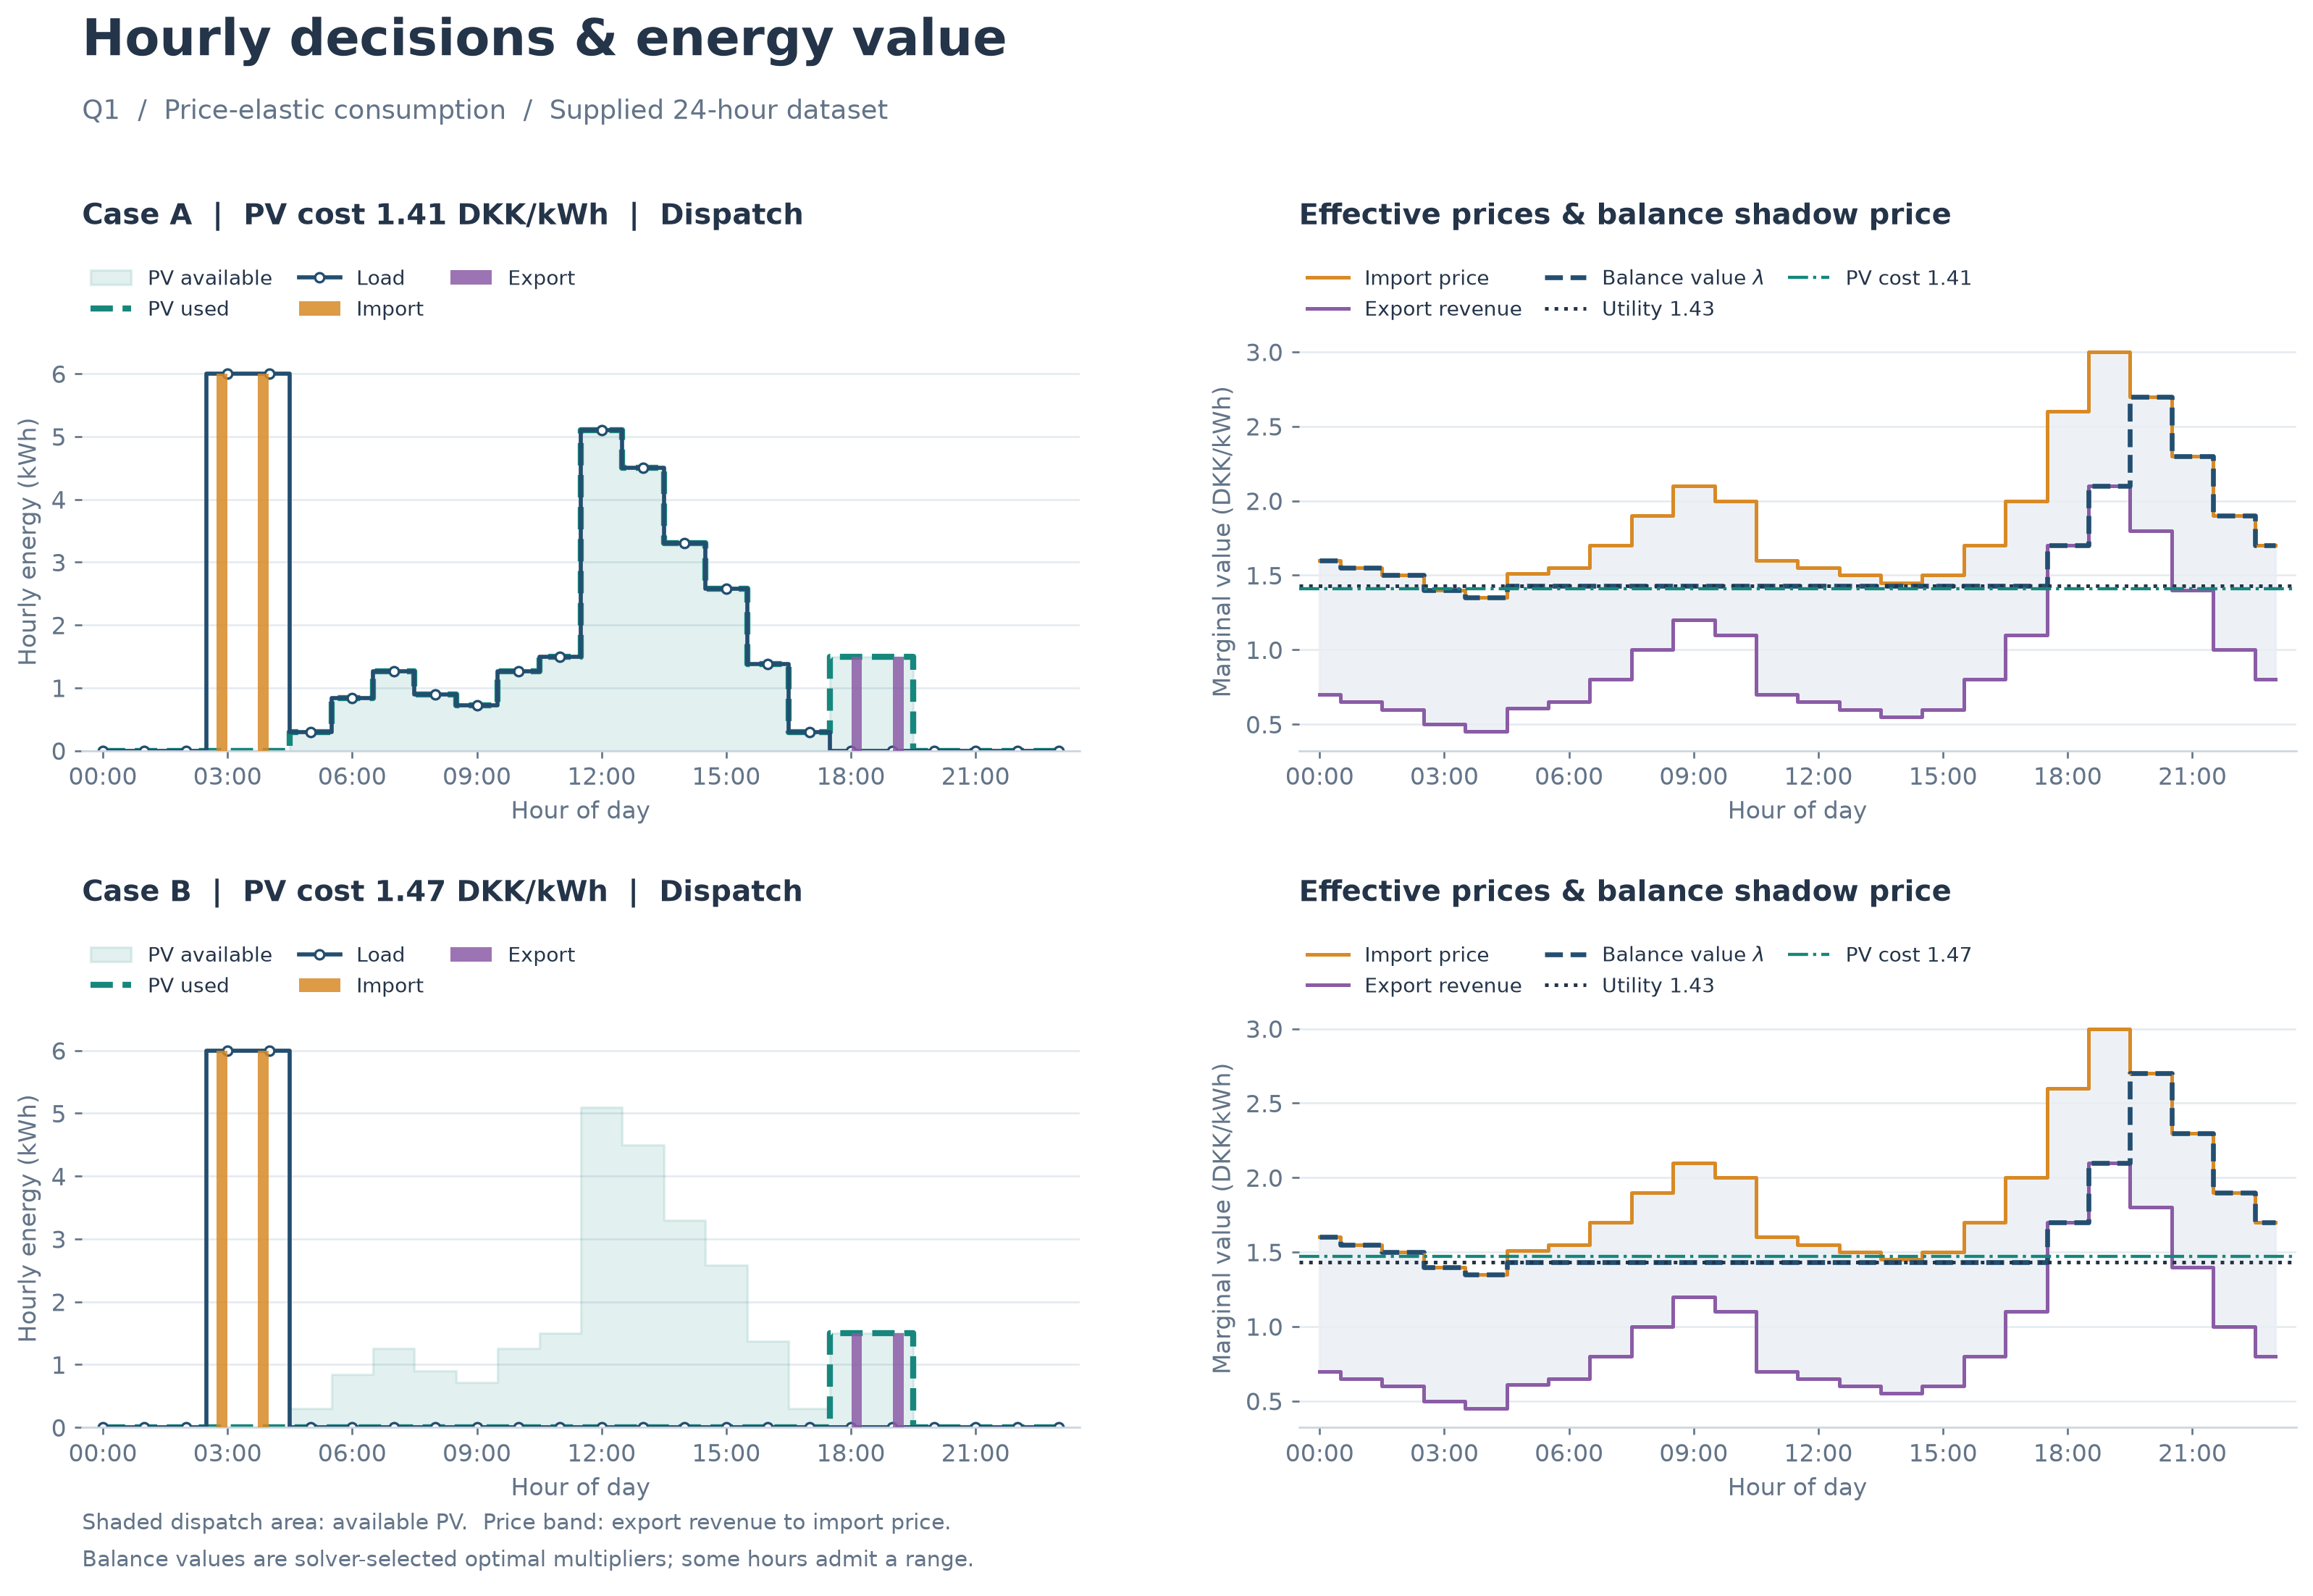

In [3]:
display(Image(filename=str(ROOT / 'results/q1_comparison.png')))

#### Corresponding bar charts

The hourly grouped bars show the same quantities and prices as the preceding line charts. The daily bars compare energy totals, procurement, gross utility and net surplus; each panel states its units.

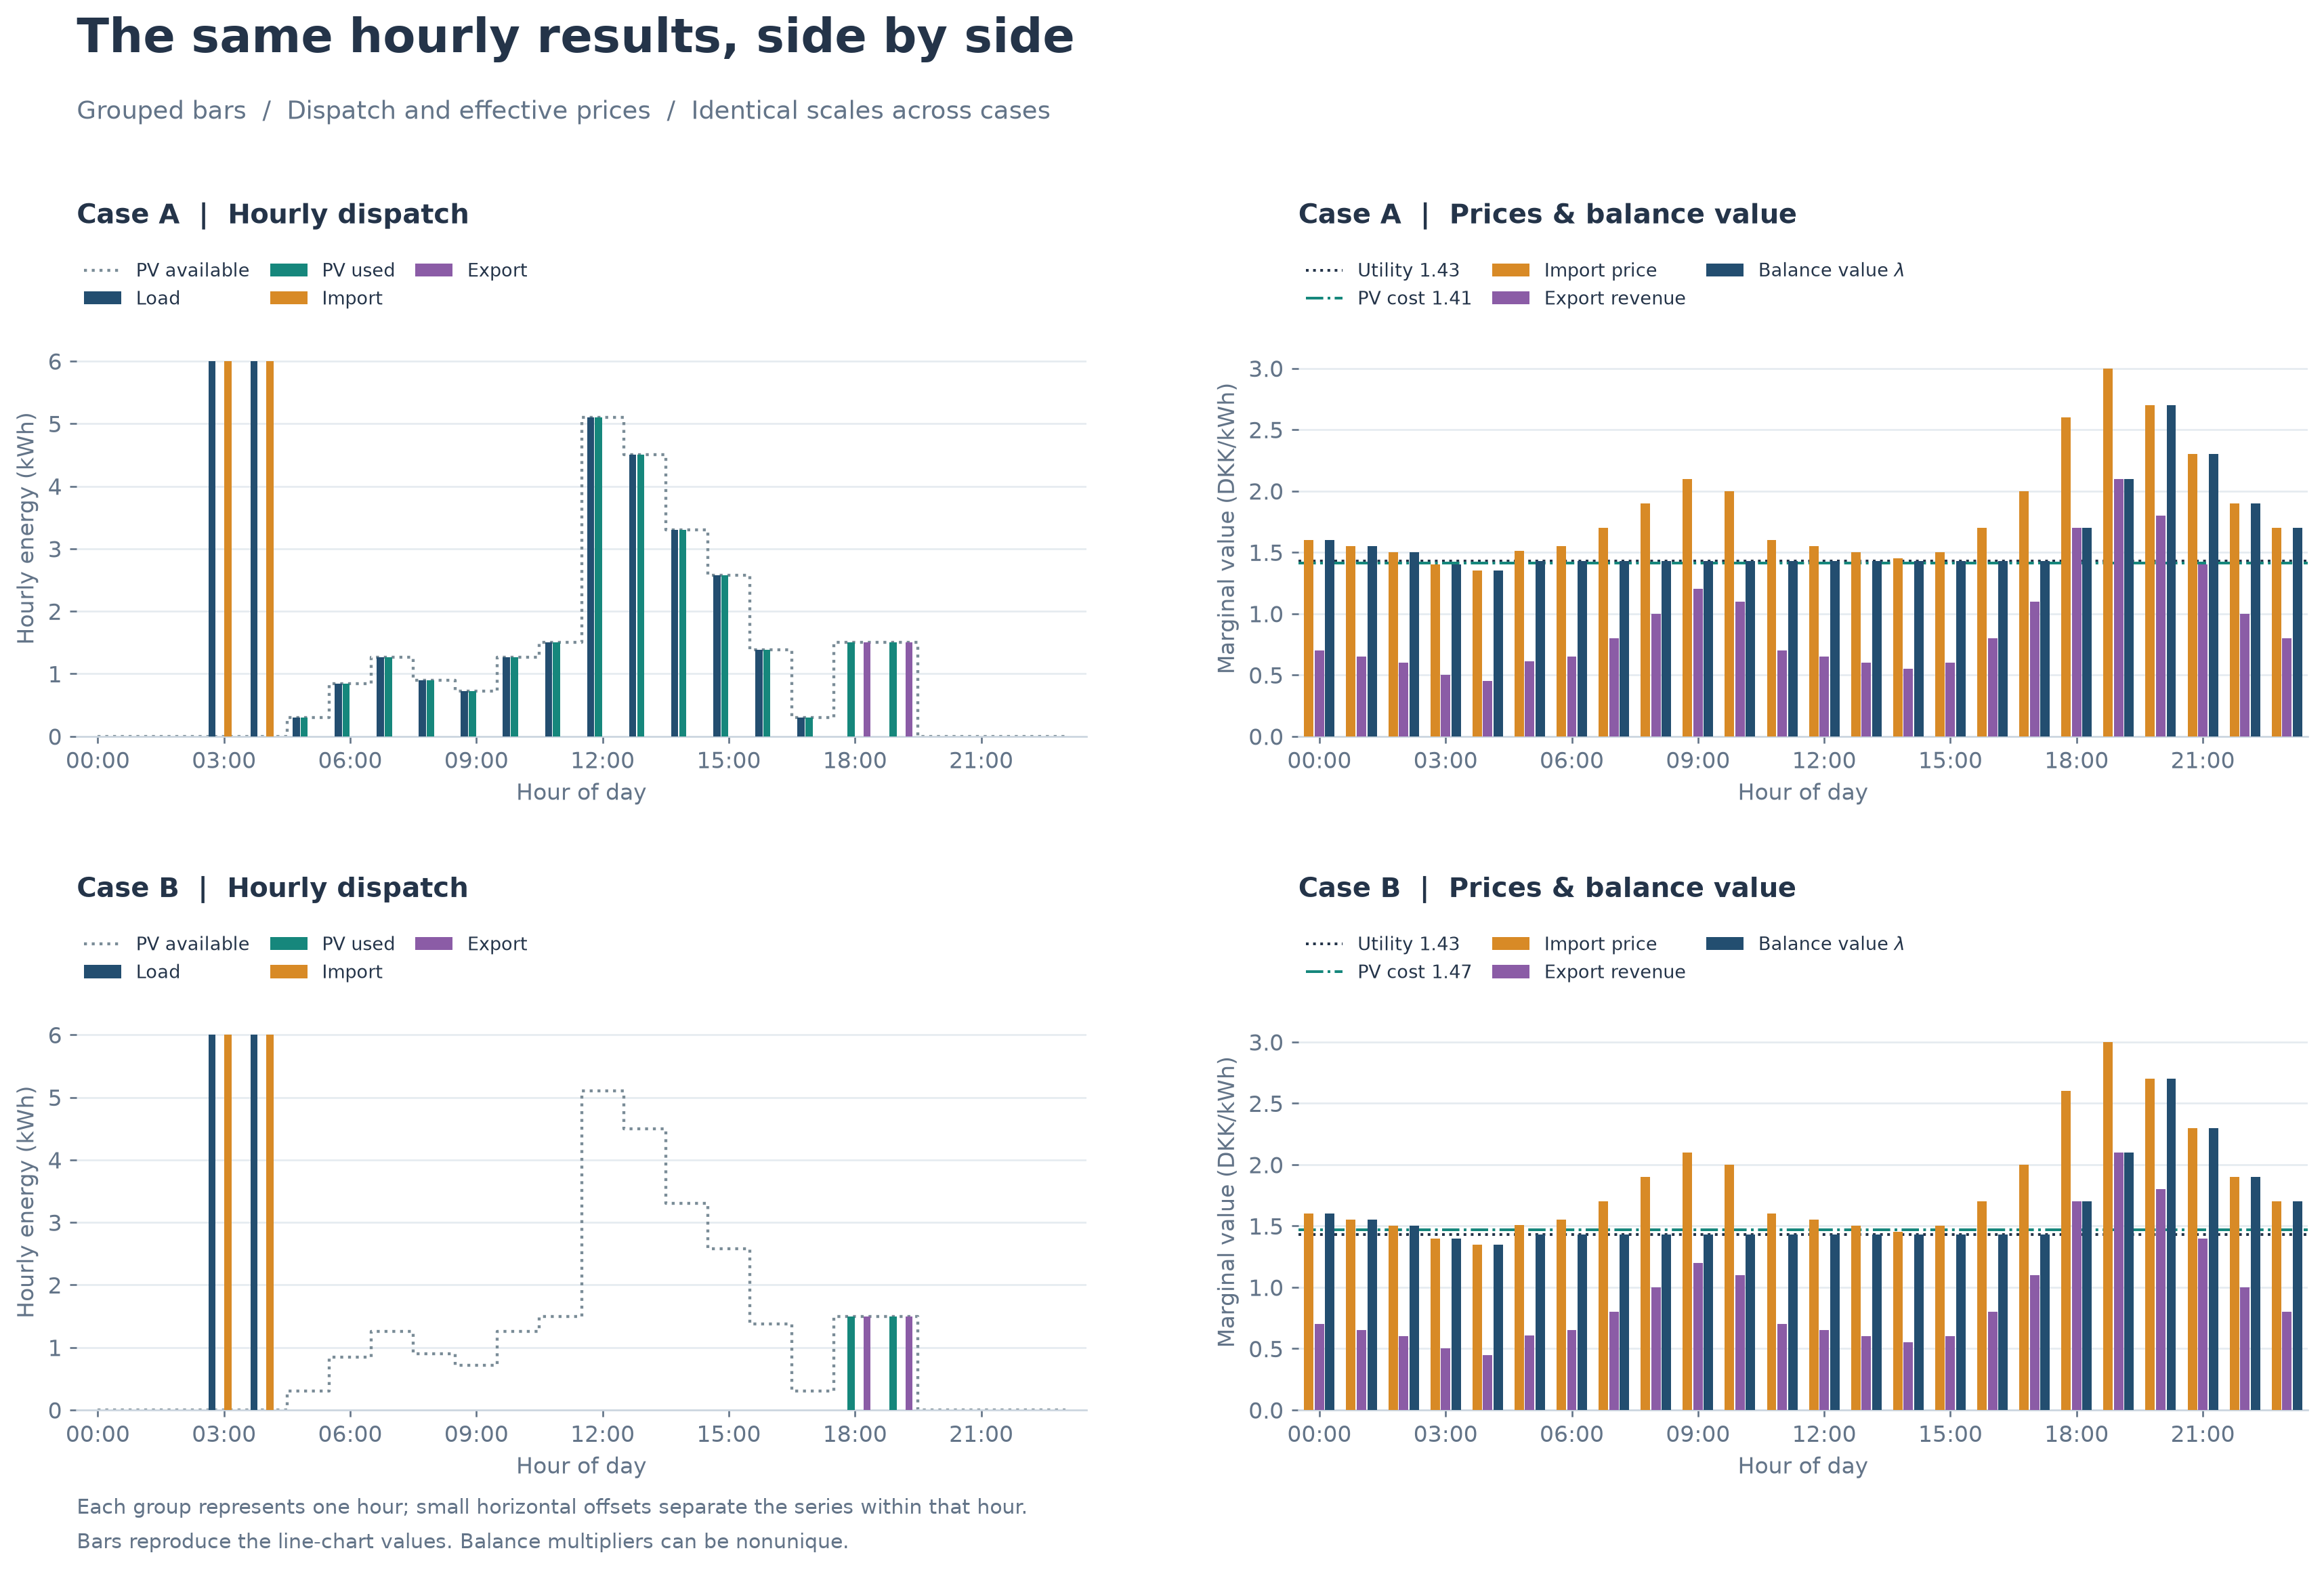

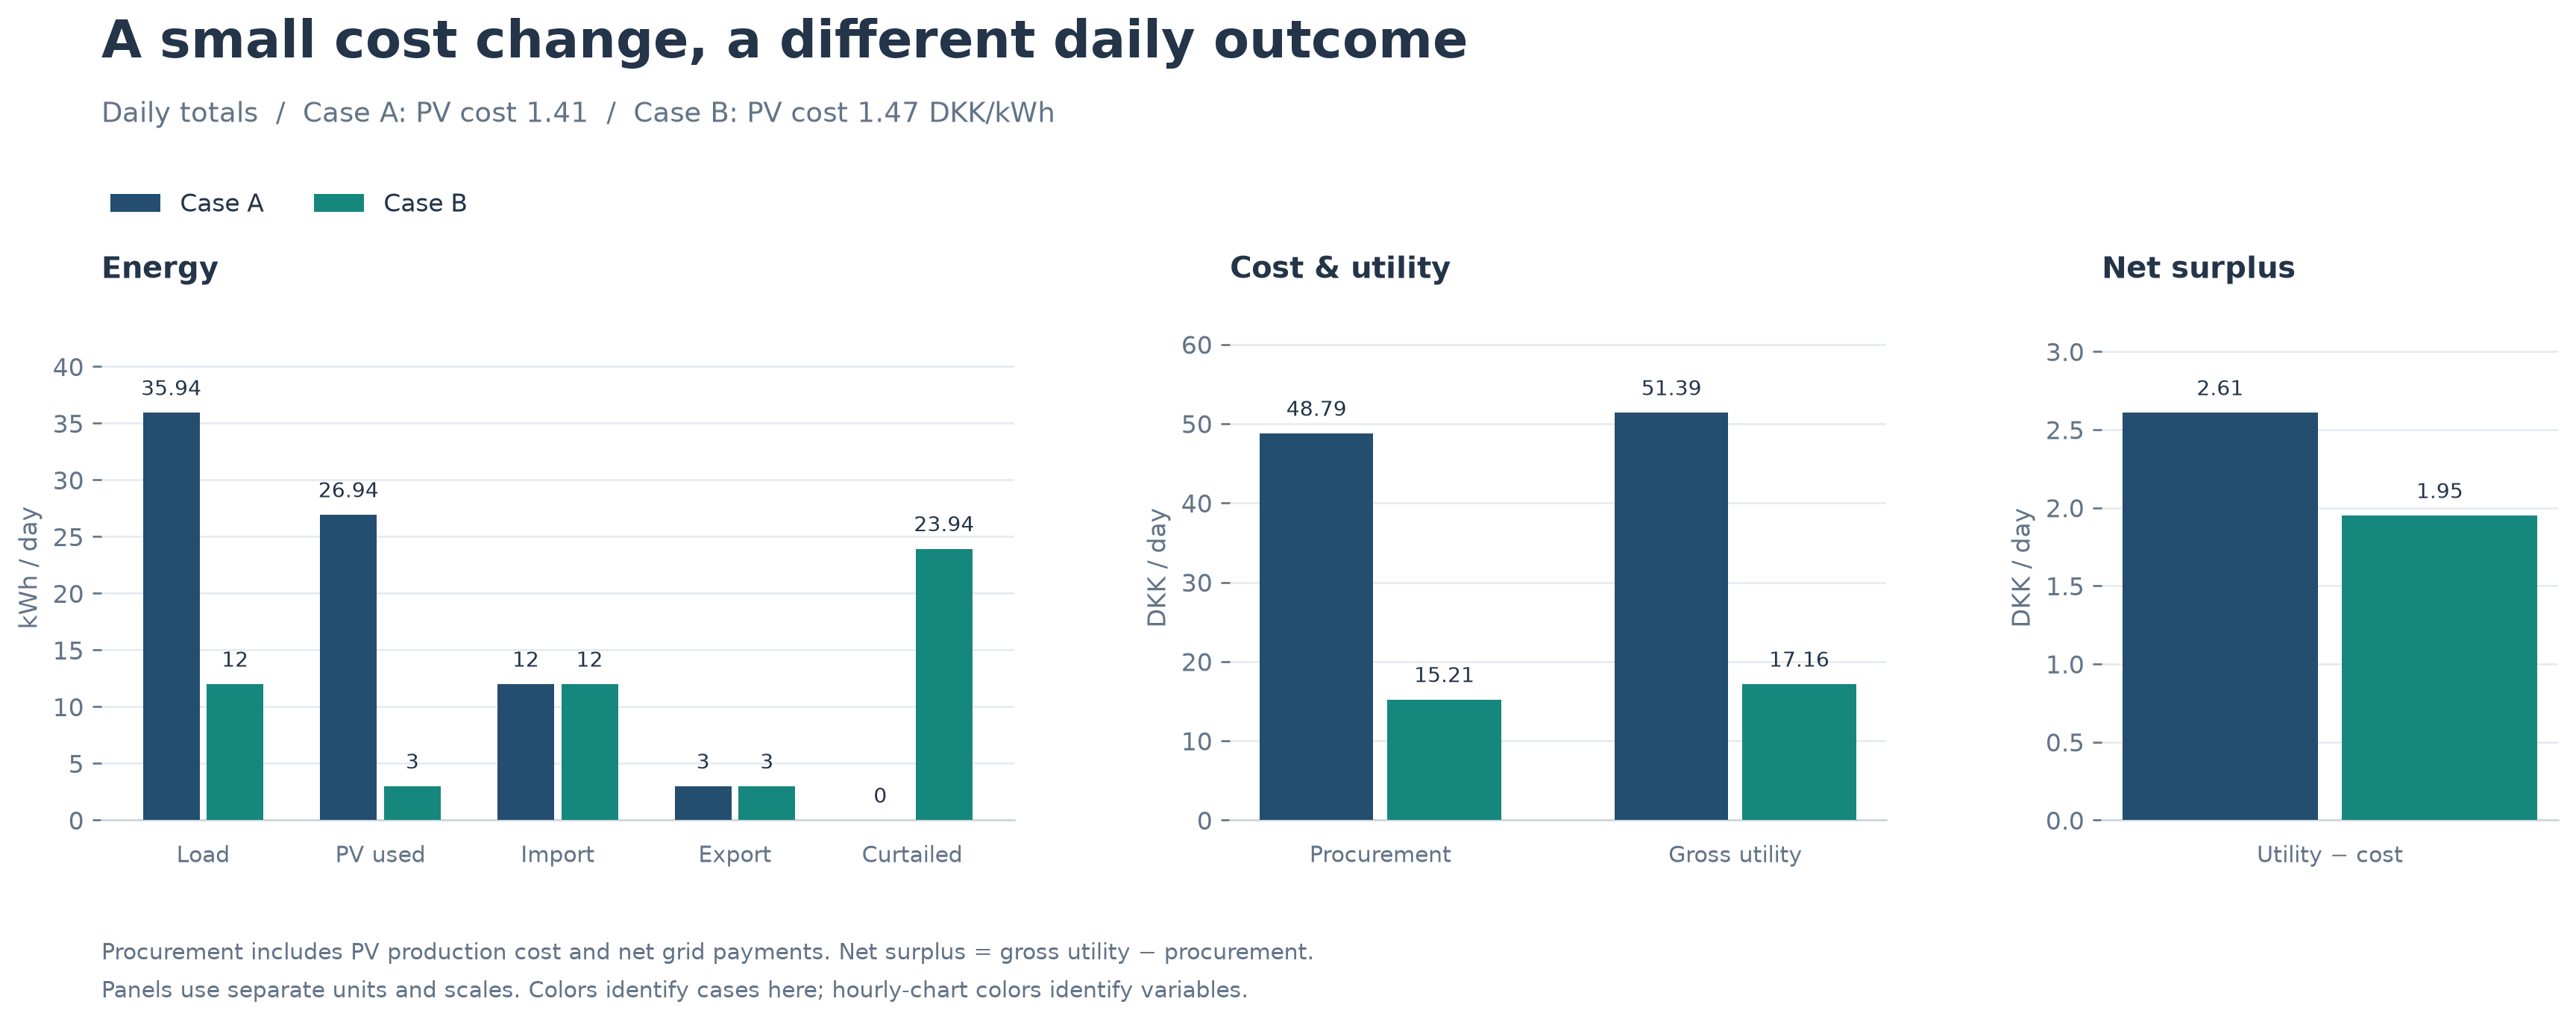

In [4]:
display(Image(filename=str(ROOT / 'results/q1_hourly_bars.png')))
display(Image(filename=str(ROOT / 'results/q1_daily_bars.png')))

### Case A: hourly ladder validation

* **Hours 3 and 4:** effective import prices are 1.40 and 1.35, below $u=1.43$. Load reaches 6 kWh each hour, supplied entirely by the grid because $V=0$. The upper-load values are $u-a=0.03$ and 0.08 DKK/kWh. These hours contribute $6(0.03+0.08)=0.66$ DKK of surplus.
* **Hours 5-17:** $b<u<a$ and $0<V<6$. Every hour has $L=G=V$, no import/export, $\lambda=u=1.43$ and $\beta^+=u-c=0.02$ DKK/kWh. Total self-consumption is 23.94 kWh, yielding 0.4788 DKK surplus. Load rises and falls with available PV because its utility slightly exceeds PV cost, whereas grid imports are too expensive and exports less valuable than consumption.
* **Hours 18 and 19:** export prices 1.70 and 2.10 exceed utility. Load drops to zero and all 1.5 kWh of available PV in each hour is exported. Balance multipliers equal export prices. Lower-load multipliers are 0.27 and 0.67; PV upper-bound multipliers are 0.29 and 0.69 DKK/kWh. Export surplus is $1.5(1.70-1.41)+1.5(2.10-1.41)=1.47$ DKK.
* **Hours 0-2 and 20-23:** $V=0$ and buying electricity is not worthwhile, so all primal flows and load are zero. The clipped ladder handles these hours even though the strict assumption $l<V<M$ fails. In particular hour 20 has $b>u$ but no PV to export.

Every hour agrees with the derived load and PV rules. There is no PV curtailment in Case A: all available generation is either consumed or exported. No hour has simultaneous positive import/export. The included hourly tables show actual quantities, analytically predicted load intervals and PASS/FAIL, so the verification is not merely a comparison of daily totals.



In [5]:
h = runs['Q1_caseA'].hourly
display(h[['price_import','price_export','pv_available','load','pv','import','export','analytical_load_min','analytical_load_max','ladder_pass','pv_regime']])
assert h['ladder_pass'].all()

,price_import,price_export,pv_available,load,pv,import,export,analytical_load_min,analytical_load_max,ladder_pass,pv_regime
hour,,,,,,,,,,,
0,1.60,0.70,0.00,0.00,0.00,0.0,0.0,0.00,0.00,True,unavailable
1,1.55,0.65,0.00,0.00,0.00,0.0,0.0,0.00,0.00,True,unavailable
2,1.50,0.60,0.00,0.00,0.00,0.0,0.0,0.00,0.00,True,unavailable
3,1.40,0.50,0.00,6.00,0.00,6.0,0.0,6.00,6.00,True,unavailable
4,1.35,0.45,0.00,6.00,0.00,6.0,0.0,6.00,6.00,True,unavailable
5,1.51,0.61,0.30,0.30,0.30,0.0,0.0,0.30,0.30,True,full
6,1.55,0.65,0.84,0.84,0.84,0.0,0.0,0.84,0.84,True,full
7,1.70,0.80,1.26,1.26,1.26,0.0,0.0,1.26,1.26,True,full
8,1.90,1.00,0.90,0.90,0.90,0.0,0.0,0.90,0.90,True,full


### Case B: what changes when $c>u$?

The Case A assumption $c<u$ is essential. It is no longer profitable to generate PV solely for optional consumption: each such kWh produces utility 1.43 but costs 1.47. Under this dataset's $l=0$, away from ties the Case B rules simplify to

$$L^*=\begin{cases}6,&u>a,\\0,&u<a,\end{cases}\qquad
G^*=\begin{cases}V,&b>c,\\0,&b<c.\end{cases}$$

Since $b<a$ and $c>u$, the two positive regimes cannot coincide. If $u=a$, load is indifferent over its admissible range with generation off; if $b=c$, PV production is indifferent over $[0,V]$ with load zero. These simplified formulas use $l=0$; with compulsory positive load the general fixed-load PV rule and piecewise analysis from (e) must be used.

Consequently, hours 3-4 still import 6 kWh each, hours 18-19 still export 1.5 kWh each, but hours 5-17 now have zero load and zero PV generation. Their 23.94 kWh of available PV is curtailed. Imports/exports are identical between the cases, while gross utility and generation both fall sharply.

The difference in net surplus is

$$S_A-S_B=0.4788+3(1.47-1.41)=0.6588\ \mathrm{DKK}.$$

The first term is the lost daytime self-consumption surplus; the second is the increased cost of the 3 kWh still generated for export. Case B's lower daily procurement cost is therefore **not** an improvement in the objective: gross consumption utility falls even more. This stark change is a consequence of a linear utility with freely disposable demand and no daily energy requirement, rather than evidence that realistic consumers can switch off every daytime demand.



In [6]:
h = runs['Q1_caseB'].hourly
display(h[['price_import','price_export','pv_available','load','pv','import','export','analytical_load_min','analytical_load_max','ladder_pass','pv_regime']])
assert h['ladder_pass'].all()

,price_import,price_export,pv_available,load,pv,import,export,analytical_load_min,analytical_load_max,ladder_pass,pv_regime
hour,,,,,,,,,,,
0,1.60,0.70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,True,unavailable
1,1.55,0.65,0.00,0.0,0.0,0.0,0.0,0.0,0.0,True,unavailable
2,1.50,0.60,0.00,0.0,0.0,0.0,0.0,0.0,0.0,True,unavailable
3,1.40,0.50,0.00,6.0,0.0,6.0,0.0,6.0,6.0,True,unavailable
4,1.35,0.45,0.00,6.0,0.0,6.0,0.0,6.0,6.0,True,unavailable
5,1.51,0.61,0.30,0.0,0.0,0.0,0.0,0.0,0.0,True,off
6,1.55,0.65,0.84,0.0,0.0,0.0,0.0,0.0,0.0,True,off
7,1.70,0.80,1.26,0.0,0.0,0.0,0.0,0.0,0.0,True,off
8,1.90,1.00,0.90,0.0,0.0,0.0,0.0,0.0,0.0,True,off


### Dual values, degeneracy and nonuniqueness

The interpretation follows the lecture's marginal-unit argument: an interior flexible load fixes the balance value at its utility [Pricing, p. 69], while a gap between marginal values can leave a price interval [Pricing, p. 25]. The intervals below are derived from this prosumer's KKT equations, rather than copied from the lecture's system-wide merit-order example. Sensitivity claims use the differentiability qualification in [Duality, p. 86].

The CSV `dual_ranges.csv` contains the minimum and maximum of **every** multiplier over all optimal dual solutions, alongside the solver-selected value. Bounds marked `inf` represent an actual unbounded dual ray, not an unbounded primal objective. Ranges are marginal projections of the joint dual feasible set; their endpoints for different multipliers cannot necessarily be combined independently.

For both cases, hours 3-4 import and have unique $\lambda=1.40,1.35$; hours 18-19 export and have unique $\lambda=1.70,2.10$. Case A additionally has unique $\lambda=1.43$ at hours 5-17. Since $0<V$ and load is interior there, all its hourly dual multipliers are unique.

At inactive hours with $V=L=G=I=X=0$,

$$\lambda\in[\max(u,b),a],\quad
\alpha^-=\lambda-u,\quad\alpha^+=0,\quad
\gamma^I=a-\lambda,\quad\gamma^X=\lambda-b.$$

The PV pair satisfies $\beta^+-\beta^-=\lambda-c$ and admits a common nonnegative increment. For example, hour 0 in Case A has $\lambda\in[1.43,1.60]$; the solver returned $\lambda=1.60$ and $\beta^+=0.19$. However, the right-hand value of introducing a tiny amount of PV is just $u-c=0.02$ DKK/kWh: it is consumed locally. The exported dual range is $\beta^+\in[0.02,\infty)$. Thus reporting 0.19 as the unique marginal value of an extra kWh of PV would be misleading.

At hour 20 in Case A, the range is $\lambda\in[1.80,2.70]$. The right-hand PV value is $b-c=0.39$ because marginal new PV would be exported. In Case B, the corresponding right-hand value is $1.80-1.47=0.33$. A PV perturbation at an importing zero-PV hour 3 or 4 has zero value because PV production is more expensive than grid imports; the coincident lower/upper PV bounds nevertheless allow nonunique PV multipliers.

At hours 5-17 in **Case B**, load and PV production are both zero although $V>0$. The PV upper bound is slack and $\beta^+=0$. Stationarity implies

$$\lambda\in[u,\min(a,c)],\qquad
\alpha^-=\lambda-u,\qquad\beta^-=c-\lambda.$$

This is $[1.43,1.47]$ except at hour 14, where $a=1.45$ and the interval is $[1.43,1.45]$. The solver selects 1.43, but that is not uniquely determined. All primal quantities remain unique: both buying electricity and producing PV for consumption have negative incremental surplus, and exporting PV is also unprofitable. Nonunique duals here occur even without an equality between utility and any effective price.



In [7]:
ranges = pd.read_csv(ROOT / 'results/dual_ranges.csv')
display(ranges[ranges['multiplier'].eq('lambda')].reset_index(drop=True))
for case, result in runs.items():
    print(case, '- solver-selected report multipliers')
    display(result.hourly[['lambda','mu_load_lower','mu_load_upper','mu_pv_lower','mu_pv_upper','mu_import_lower','mu_export_lower']])
print('All multiplier ranges, including nonunique PV bound pairs, are in results/dual_ranges.csv.')

,case,hour,multiplier,reported,minimum,maximum,unique
0,Q1_caseA,0,lambda,1.60,1.43,1.60,False
1,Q1_caseA,1,lambda,1.55,1.43,1.55,False
2,Q1_caseA,2,lambda,1.50,1.43,1.50,False
3,Q1_caseA,3,lambda,1.40,1.40,1.40,True
4,Q1_caseA,4,lambda,1.35,1.35,1.35,True
5,Q1_caseA,5,lambda,1.43,1.43,1.43,True
6,Q1_caseA,6,lambda,1.43,1.43,1.43,True
7,Q1_caseA,7,lambda,1.43,1.43,1.43,True
8,Q1_caseA,8,lambda,1.43,1.43,1.43,True
9,Q1_caseA,9,lambda,1.43,1.43,1.43,True


Q1_caseA - solver-selected report multipliers


,lambda,mu_load_lower,mu_load_upper,mu_pv_lower,mu_pv_upper,mu_import_lower,mu_export_lower
hour,,,,,,,
0,1.60,0.17,-0.00,-0.00,0.19,-0.00,0.90
1,1.55,0.12,-0.00,-0.00,0.14,-0.00,0.90
2,1.50,0.07,-0.00,-0.00,0.09,-0.00,0.90
3,1.40,-0.00,0.03,0.01,-0.00,-0.00,0.90
4,1.35,-0.00,0.08,0.06,-0.00,-0.00,0.90
5,1.43,-0.00,-0.00,-0.00,0.02,0.08,0.82
6,1.43,-0.00,-0.00,-0.00,0.02,0.12,0.78
7,1.43,-0.00,-0.00,-0.00,0.02,0.27,0.63
8,1.43,-0.00,-0.00,-0.00,0.02,0.47,0.43


Q1_caseB - solver-selected report multipliers


,lambda,mu_load_lower,mu_load_upper,mu_pv_lower,mu_pv_upper,mu_import_lower,mu_export_lower
hour,,,,,,,
0,1.60,0.17,-0.00,-0.00,0.13,-0.00,0.90
1,1.55,0.12,-0.00,-0.00,0.08,-0.00,0.90
2,1.50,0.07,-0.00,-0.00,0.03,-0.00,0.90
3,1.40,-0.00,0.03,0.07,-0.00,-0.00,0.90
4,1.35,-0.00,0.08,0.12,-0.00,-0.00,0.90
5,1.43,-0.00,-0.00,0.04,-0.00,0.08,0.82
6,1.43,-0.00,-0.00,0.04,-0.00,0.12,0.78
7,1.43,-0.00,-0.00,0.04,-0.00,0.27,0.63
8,1.43,-0.00,-0.00,0.04,-0.00,0.47,0.43


All multiplier ranges, including nonunique PV bound pairs, are in results/dual_ranges.csv.


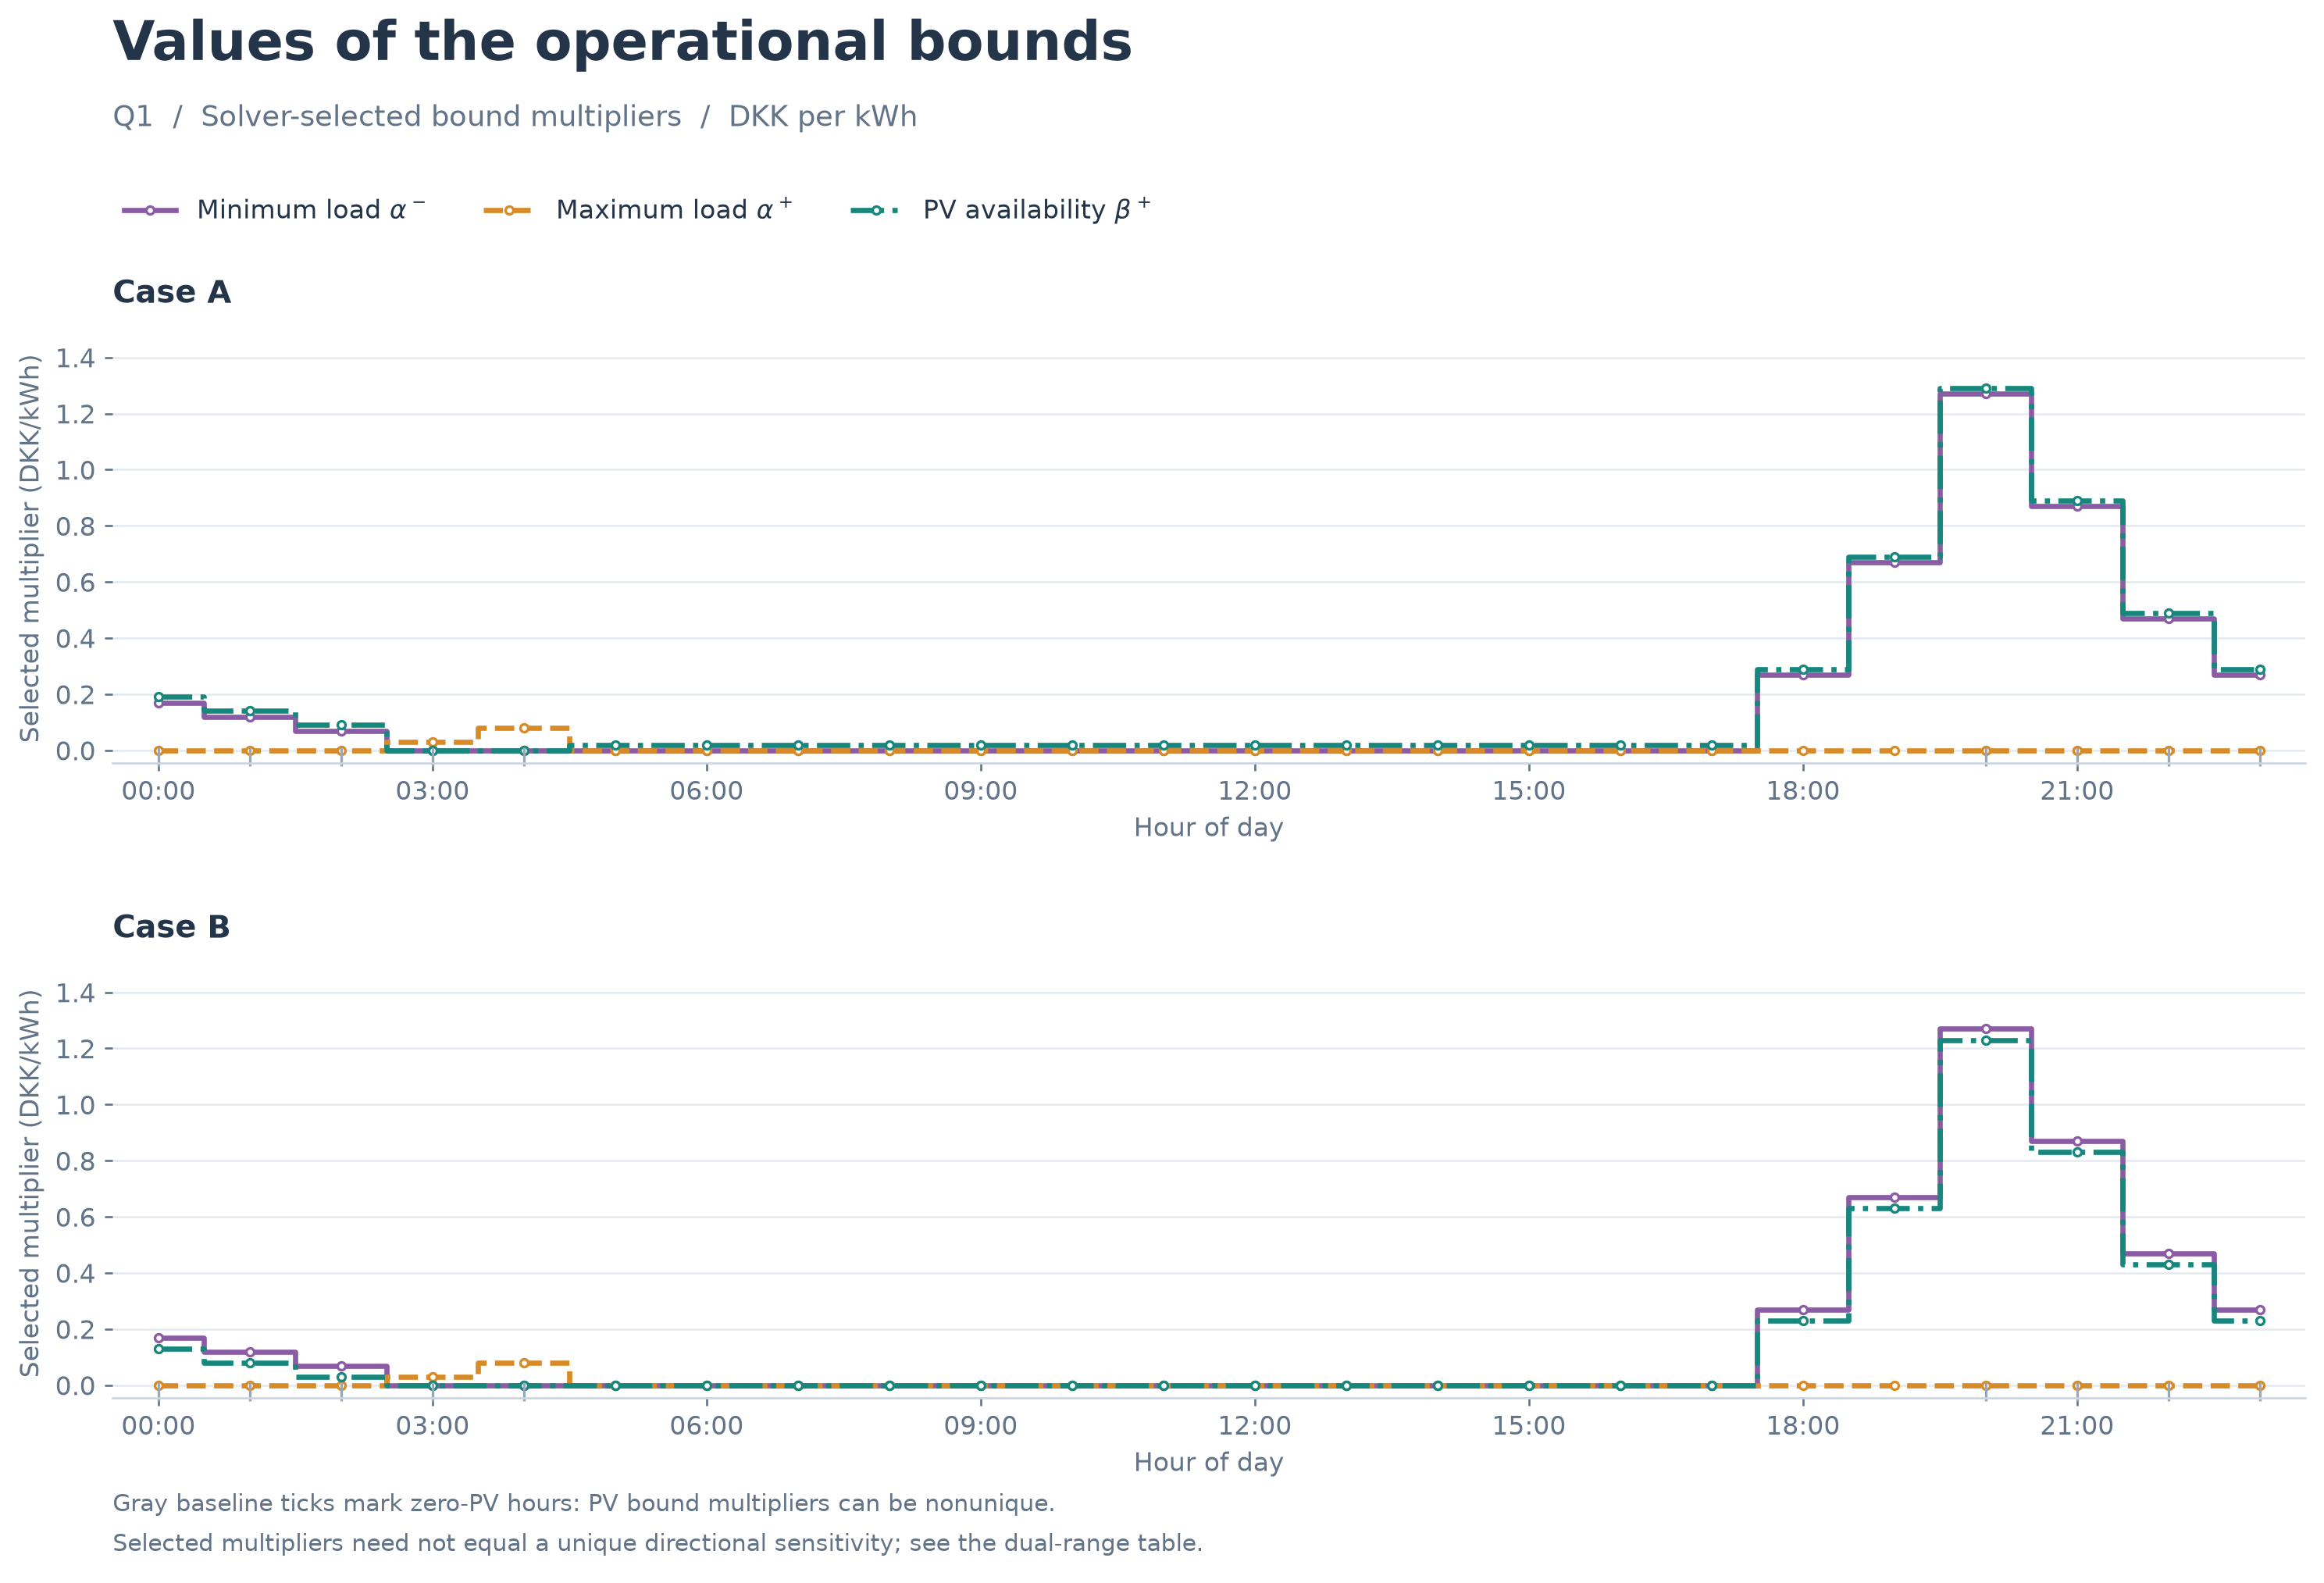

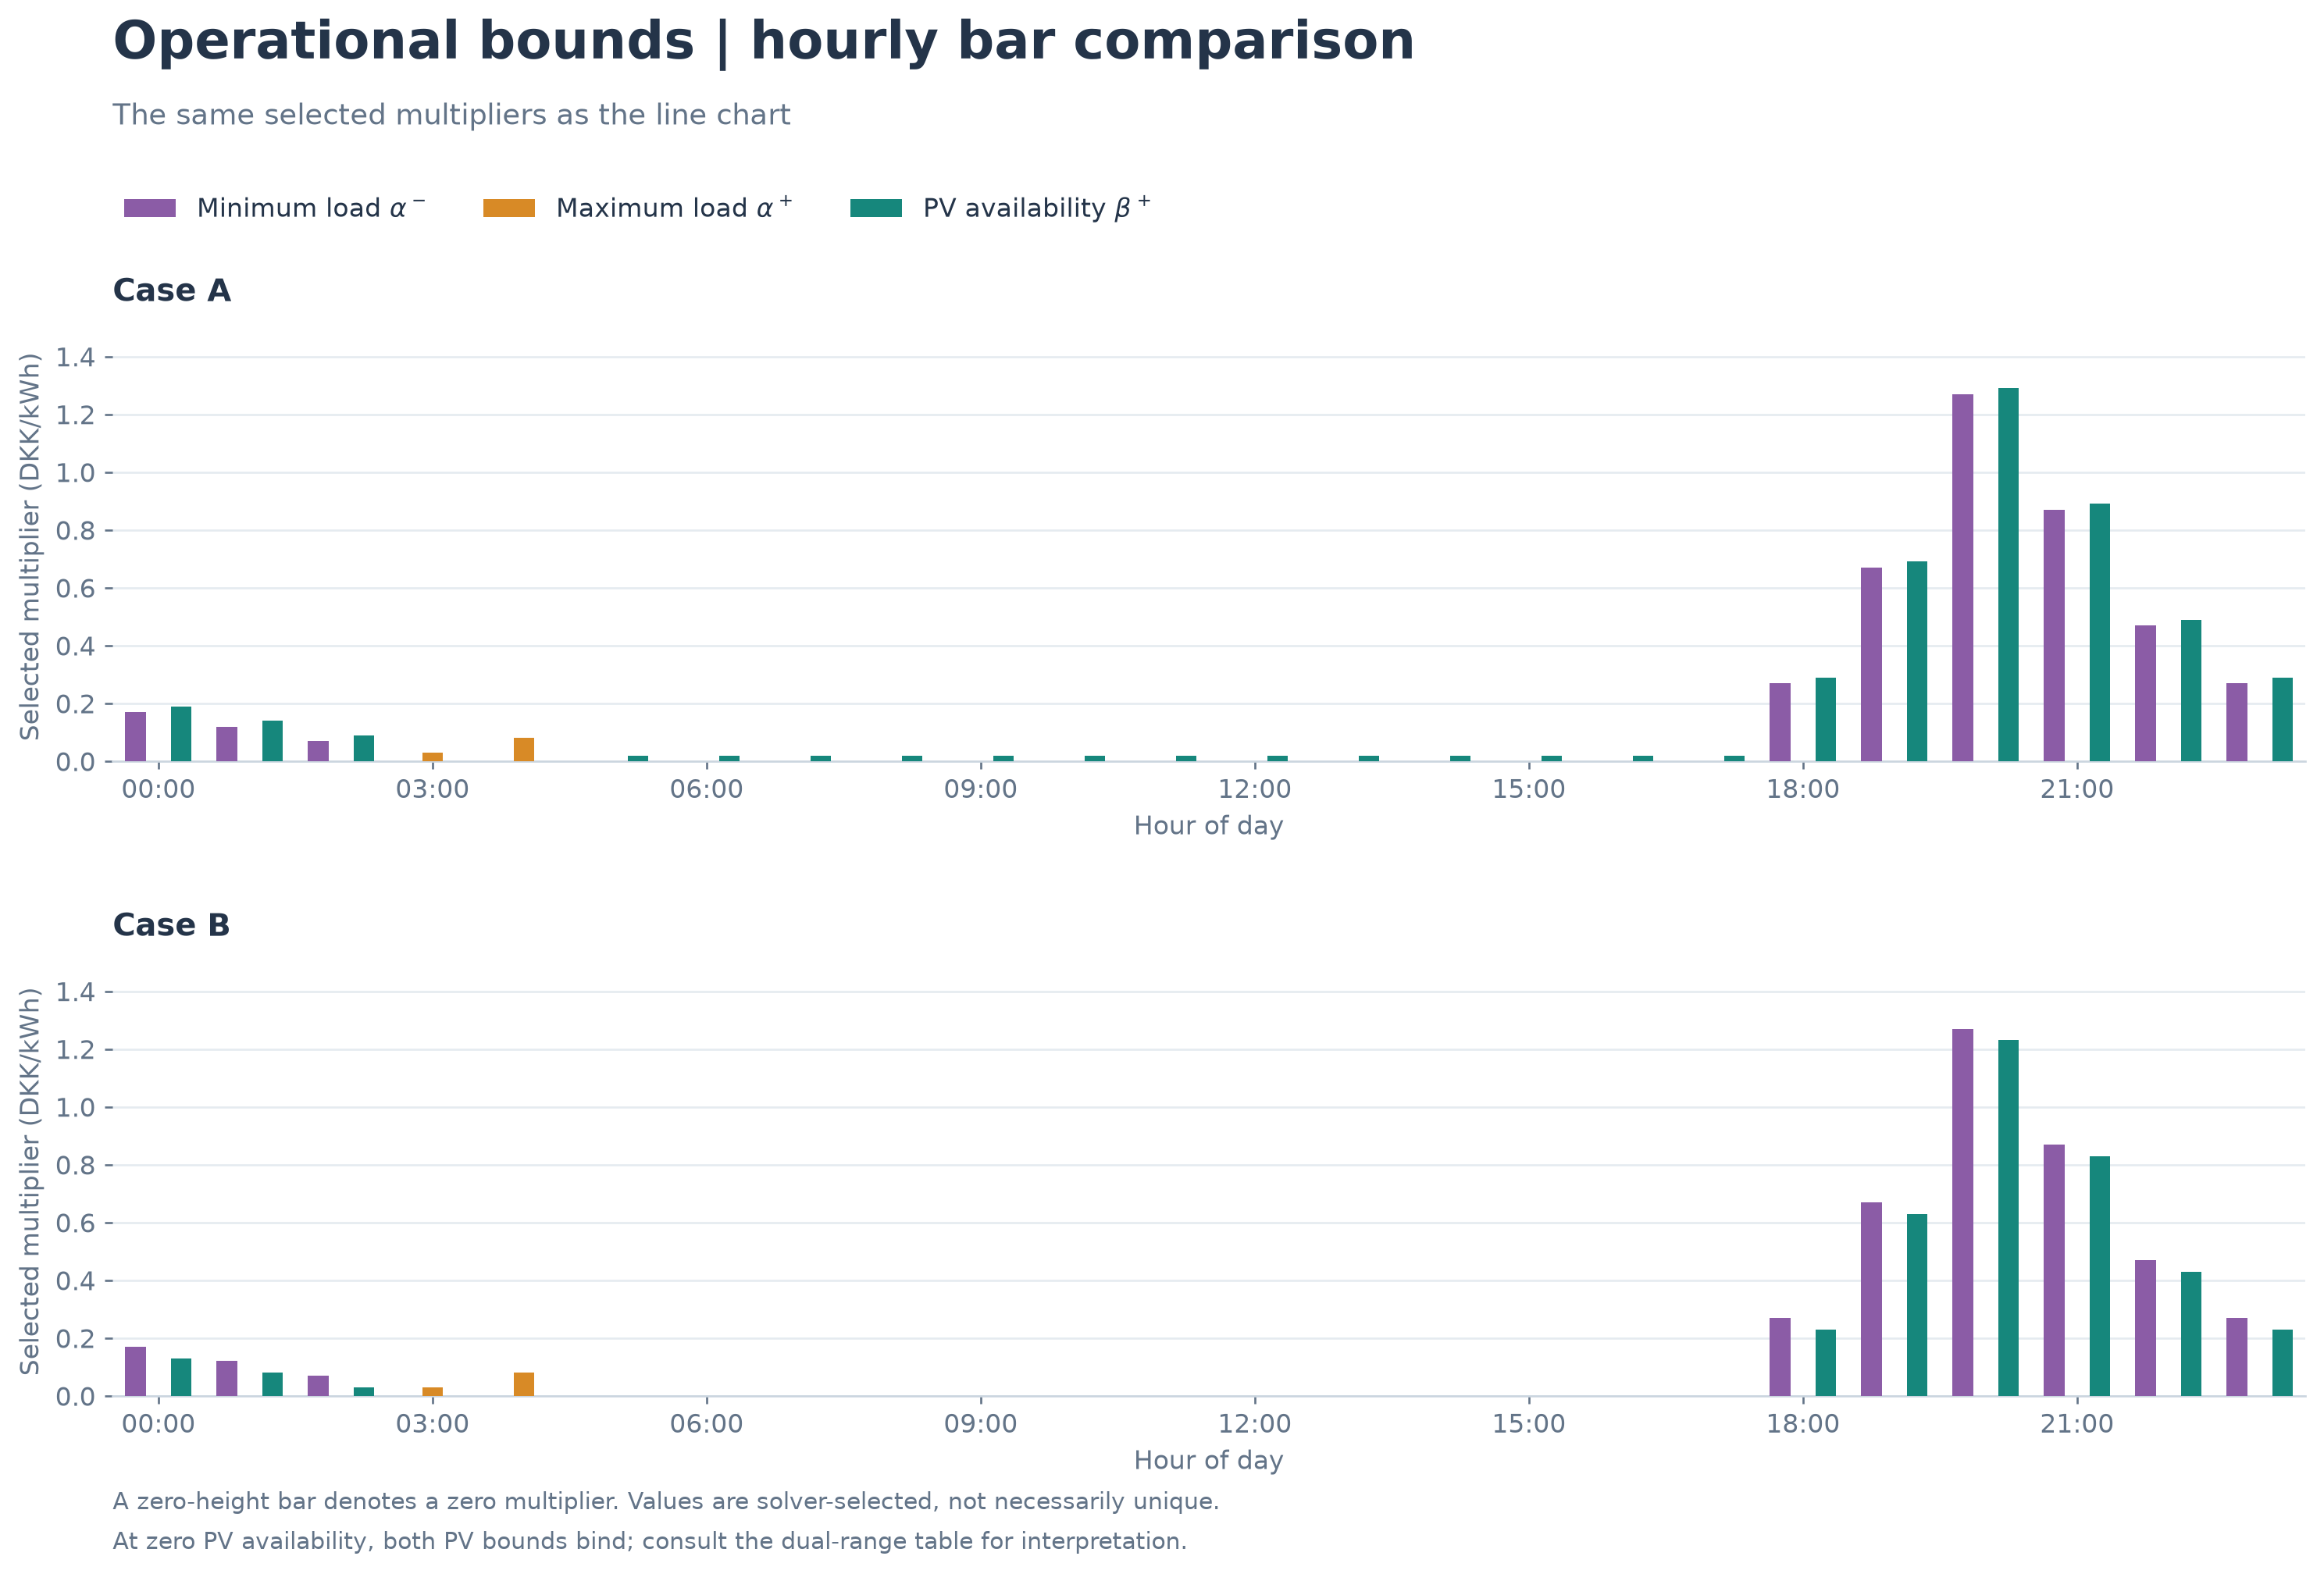

,case,hour,multiplier,reported,minimum,maximum,unique
4,Q1_caseA,0,mu_pv_upper,0.19,0.02,inf,False
25,Q1_caseA,3,mu_pv_upper,-0.00,0.00,inf,False
39,Q1_caseA,5,mu_pv_upper,0.02,0.02,0.02,True
102,Q1_caseA,14,mu_pv_upper,0.02,0.02,0.02,True
144,Q1_caseA,20,mu_pv_upper,1.29,0.39,inf,False
172,Q1_caseB,0,mu_pv_upper,0.13,0.00,inf,False
193,Q1_caseB,3,mu_pv_upper,-0.00,0.00,inf,False
207,Q1_caseB,5,mu_pv_upper,-0.00,0.00,-0.00,True
270,Q1_caseB,14,mu_pv_upper,-0.00,0.00,-0.00,True
312,Q1_caseB,20,mu_pv_upper,1.23,0.33,inf,False


In [8]:
display(Image(filename=str(ROOT / 'results/q1_duals.png')))
display(Image(filename=str(ROOT / 'results/q1_duals_bars.png')))
display(ranges[(ranges['hour'].isin([0,3,5,14,20])) & (ranges['multiplier'].eq('mu_pv_upper'))])

### Verification results and interpretation

Both 24-hour cases solved to optimality and passed all 48 hourly analytical checks. Maximum hourly primal-dual objective discrepancy was below $2\times10^{-15}$ DKK; balance, stationarity and complementarity residuals were within the $10^{-7}$ validation tolerance. Import/export overlap was zero. The additional automated tests check 20 randomized 24-hour datasets and six 24-hour edge-case datasets, including ties and PV outside load bounds, plus finite-difference sensitivity and a dual ray. These are software checks and are separate from the base-case economic conclusions.

The main economic distinction is the destination value of PV: it is worth $u$ when consumed at an interior optimum, $b$ when exported, or $a$ when replacing imports. Raising its production cost through the consumption utility threshold removes voluntary self-consumption while preserving profitable export opportunities. Tariffs sustain the gap between buying and selling incentives and prevent circular grid trades.


In [9]:
checks = json.loads((ROOT / 'results/validation.json').read_text())
display(pd.DataFrame(checks))
import subprocess
tests = subprocess.run([sys.executable, str(ROOT / 'test_q1.py')], cwd=ROOT, capture_output=True, text=True)
print(tests.stdout + tests.stderr)
assert tests.returncode == 0, 'Q1 tests failed'